In [1]:
import pandas as pd
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

import torch
from torch import nn

import matplotlib.pyplot as plt
import numpy as np

from src.models import CircleMultiClassModel_Linear, CircleMultiClassModel_NonLinear
from src.metrics_funcs import get_accuracy, precision_macro, recall_macro, f1_score_macro, get_confusion_matrix
from src.plotting_helpers import plot_test_train_decision_boundary, plot_curves

In [2]:
NUM_SAMPLES = 1000
NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42
EPOCHS = 100
save_step=10
epoch_range = np.linspace(1, EPOCHS, save_step)

device = "cuda" if torch.cuda.is_available() else "cpu"

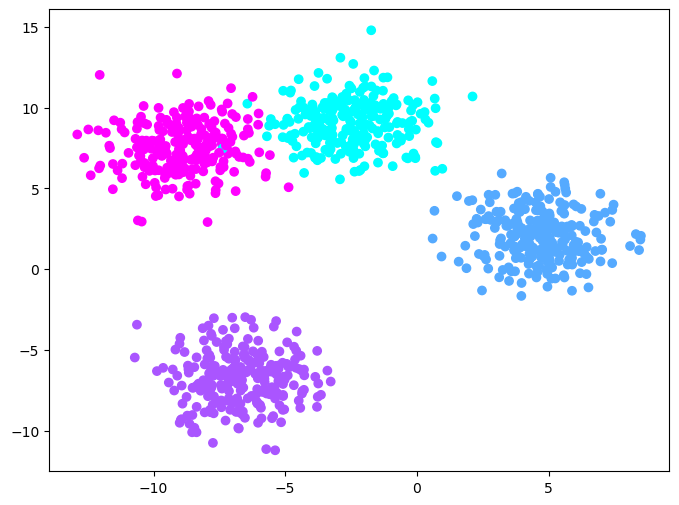

In [3]:
# Create dataset
X, y = make_blobs(n_samples=NUM_SAMPLES,
                            n_features=NUM_FEATURES,
                            centers=NUM_CLASSES,
                            cluster_std=1.5,
                            random_state=RANDOM_SEED)
# Visualize
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.cool)
plt.show()

In [4]:
# Convert to tensors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.LongTensor)

# Split into train and test sample
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

# Put everything to device
X_train, X_test = X_train.to(device), X_test.to(device)
y_train, y_test = y_train.to(device), y_test.to(device)

In [5]:
# Create instances of linear and nonlinear model
linear_model = CircleMultiClassModel_Linear(
    input_features=2,
    output_features=4,
    hidden_units=8
).to(device)

nonlinear_model = CircleMultiClassModel_NonLinear(
    input_features=2,
    output_features=4,
    hidden_units=8
).to(device)

In [6]:
# Define loss function and optimizer
loss_func = nn.CrossEntropyLoss()
liner_optimizer = torch.optim.SGD(params=linear_model.parameters(), lr=0.1)
nonliner_optimizer = torch.optim.SGD(params=nonlinear_model.parameters(), lr=0.1)

In [7]:
# Train linear model
torch.manual_seed(16)
torch.cuda.manual_seed(16)

# Track loss and accuracy
linear_train_loss_vals = []
linear_test_loss_vals = []
linear_train_acc_vals = []
linear_test_acc_vals = []

# Train loop
for epoch in range(EPOCHS):
  linear_model.train()

  y_logits = linear_model(X_train)
  y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)

  loss = loss_func(y_logits, y_train)
  accuracy = get_accuracy(y_true=y_train, y_pred=y_pred)

  liner_optimizer.zero_grad()

  loss.backward()

  liner_optimizer.step()

  # Test loop
  linear_model.eval()
  with torch.inference_mode():
    test_logits = linear_model(X_test)
    test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)

    test_loss = loss_func(test_logits, y_test)
    test_accuracy = get_accuracy(y_true=y_test, y_pred=test_pred)

  # Print
  if epoch % save_step == 0:
    print(f"Epoch: {epoch}")
    print(f"Loss: {loss:.5f} | Acc: {accuracy:.2f}")
    print(f"Test Loss: {test_loss:.5f} | Test Acc: {test_accuracy:.2f}")
    print("-----------------------------------------------------------------")
    linear_train_loss_vals.append(loss)
    linear_test_loss_vals.append(test_loss)
    linear_train_acc_vals.append(accuracy)
    linear_test_acc_vals.append(test_accuracy)

Epoch: 0
Loss: 1.84509 | Acc: 44.50
Test Loss: 0.97756 | Test Acc: 56.00
-----------------------------------------------------------------
Epoch: 10
Loss: 0.16397 | Acc: 99.12
Test Loss: 0.14913 | Test Acc: 99.50
-----------------------------------------------------------------
Epoch: 20
Loss: 0.08614 | Acc: 99.12
Test Loss: 0.07782 | Test Acc: 99.50
-----------------------------------------------------------------
Epoch: 30
Loss: 0.06160 | Acc: 99.12
Test Loss: 0.05384 | Test Acc: 99.50
-----------------------------------------------------------------
Epoch: 40
Loss: 0.05014 | Acc: 99.12
Test Loss: 0.04226 | Test Acc: 99.50
-----------------------------------------------------------------
Epoch: 50
Loss: 0.04365 | Acc: 99.12
Test Loss: 0.03556 | Test Acc: 99.50
-----------------------------------------------------------------
Epoch: 60
Loss: 0.03952 | Acc: 99.12
Test Loss: 0.03122 | Test Acc: 99.50
-----------------------------------------------------------------
Epoch: 70
Loss: 0.036

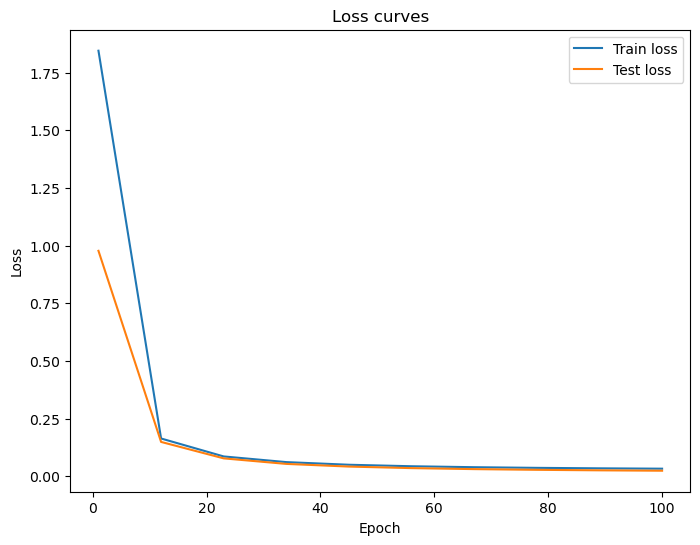

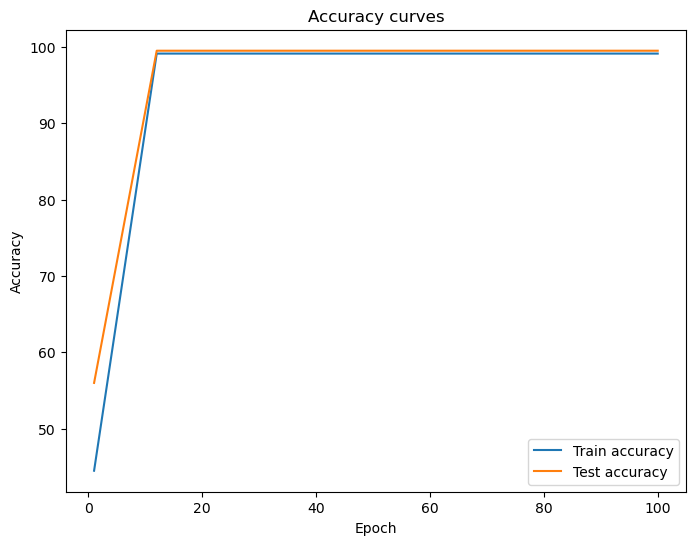

In [8]:
# Plot accuracy and loss curves
plot_curves(epoch_range, linear_train_loss_vals, linear_test_loss_vals, var_to_plot="loss", filename="linear_loss_curves.png")
plot_curves(epoch_range, linear_train_acc_vals, linear_test_acc_vals, var_to_plot="accuracy", filename="linear_accuracy_curves.png")

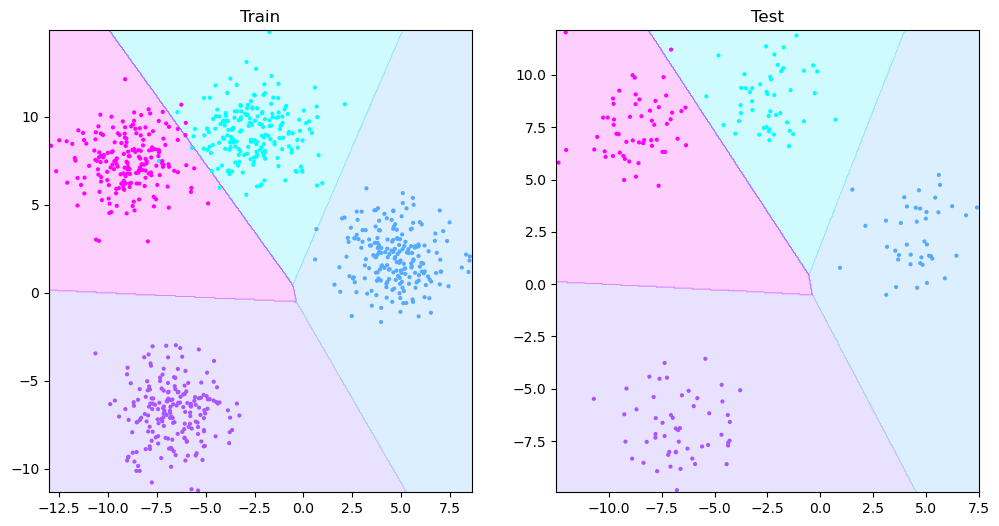

In [9]:
# Plot decision boundaries
plot_test_train_decision_boundary(linear_model, X_train, y_train, X_test, y_test, filename="linear_decision_boundary.png")

Linear model precision: 99.49999997982118
Linear model recall: 99.56140348854633
Linear model f1 score: 99.52623578422222
Not normalized


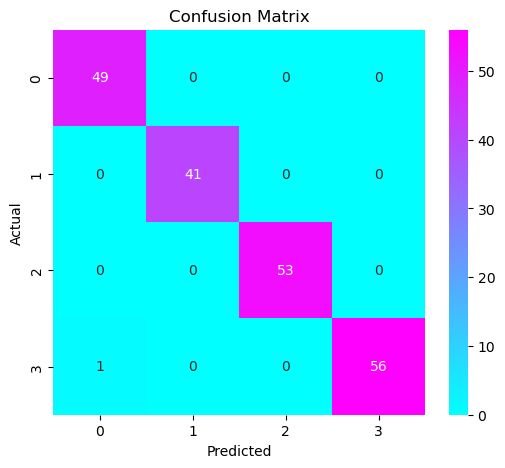

In [10]:
# Calculate metrics for linear model
linear_precision = precision_macro(
    y_true=y_test,
    y_pred=test_pred,
    num_classes=NUM_CLASSES
)
print("Linear model precision:", linear_precision)

linear_recall = recall_macro(
    y_true=y_test,
    y_pred=test_pred,
    num_classes=NUM_CLASSES
)
print("Linear model recall:", linear_recall)

linear_f1_score = f1_score_macro(
    y_true=y_test,
    y_pred=test_pred,
    num_classes=NUM_CLASSES
)
print("Linear model f1 score:", linear_f1_score)

metrics_df = pd.DataFrame({
    "train_loss": [loss.item()],
    "train_accuracy": [accuracy],
    "precision": [linear_precision],
    "recall": [linear_recall],
    "f1_score": [linear_f1_score],
})

linear_confusion_matrix = get_confusion_matrix(
    y_true=y_test,
    y_pred=test_pred,
    num_classes=NUM_CLASSES,
    normalize=None,
    cmap="cool"
)

In [11]:
# Train nonlinear model
torch.manual_seed(16)
torch.cuda.manual_seed(16)

# Track loss and accuracy
nonlinear_train_loss_vals = []
nonlinear_test_loss_vals = []
nonlinear_train_acc_vals = []
nonlinear_test_acc_vals = []

# Train loop
for epoch in range(EPOCHS):
  nonlinear_model.train()

  y_logits = nonlinear_model(X_train)
  y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)

  loss = loss_func(y_logits, y_train)
  accuracy = get_accuracy(y_true=y_train, y_pred=y_pred)

  nonliner_optimizer.zero_grad()

  loss.backward()

  nonliner_optimizer.step()

  # Test loop
  nonlinear_model.eval()
  with torch.inference_mode():
    test_logits = nonlinear_model(X_test)
    test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)

    test_loss = loss_func(test_logits, y_test)
    test_accuracy = get_accuracy(y_true=y_test, y_pred=test_pred)

  # Print
  if epoch % save_step == 0:
    print(f"Epoch: {epoch}")
    print(f"Loss: {loss:.5f} | Acc: {accuracy:.2f}")
    print(f"Test Loss: {test_loss:.5f} | Test Acc: {test_accuracy:.2f}")
    print("-----------------------------------------------------------------")
    nonlinear_train_loss_vals.append(loss)
    nonlinear_test_loss_vals.append(test_loss)
    nonlinear_train_acc_vals.append(accuracy)
    nonlinear_test_acc_vals.append(test_accuracy)

Epoch: 0
Loss: 1.39348 | Acc: 18.88
Test Loss: 1.28996 | Test Acc: 26.50
-----------------------------------------------------------------
Epoch: 10
Loss: 0.88230 | Acc: 63.38
Test Loss: 0.84432 | Test Acc: 59.50
-----------------------------------------------------------------
Epoch: 20
Loss: 0.58269 | Acc: 85.75
Test Loss: 0.56527 | Test Acc: 87.50
-----------------------------------------------------------------
Epoch: 30
Loss: 0.42227 | Acc: 89.50
Test Loss: 0.40116 | Test Acc: 92.50
-----------------------------------------------------------------
Epoch: 40
Loss: 0.33474 | Acc: 92.62
Test Loss: 0.31545 | Test Acc: 95.00
-----------------------------------------------------------------
Epoch: 50
Loss: 0.28063 | Acc: 95.50
Test Loss: 0.26400 | Test Acc: 96.00
-----------------------------------------------------------------
Epoch: 60
Loss: 0.24276 | Acc: 96.50
Test Loss: 0.22752 | Test Acc: 97.50
-----------------------------------------------------------------
Epoch: 70
Loss: 0.213

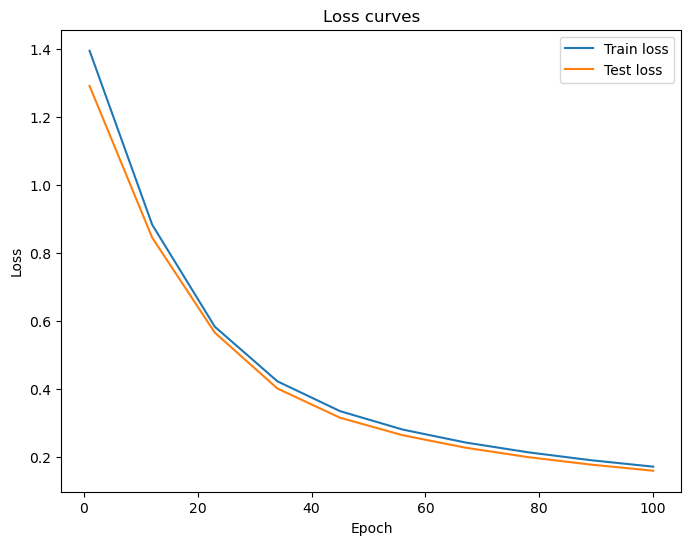

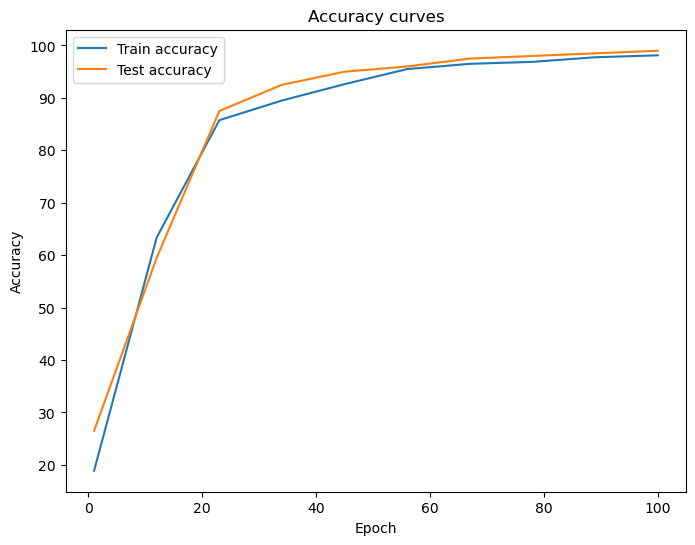

In [12]:
# Plot accuracy and loss curves
plot_curves(epoch_range, nonlinear_train_loss_vals, nonlinear_test_loss_vals, var_to_plot="loss", filename="nonlinear_loss_curves.png")
plot_curves(epoch_range, nonlinear_train_acc_vals, nonlinear_test_acc_vals, var_to_plot="accuracy", filename="nonlinear_accuracy_curves.png")

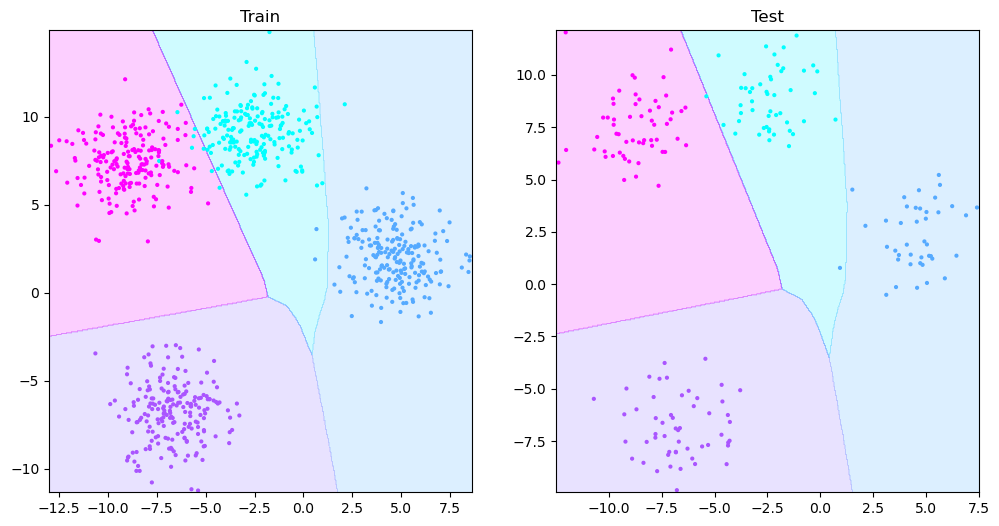

In [13]:
# Plot decision boundaries
plot_test_train_decision_boundary(nonlinear_model, X_train, y_train, X_test, y_test, filename="nonlinear_decision_boundary.png")

Nonlinear model precision: 99.0587614154078
Nonlinear model recall: 98.88003980075666
Nonlinear model f1 score: 98.96376261358961
Not normalized


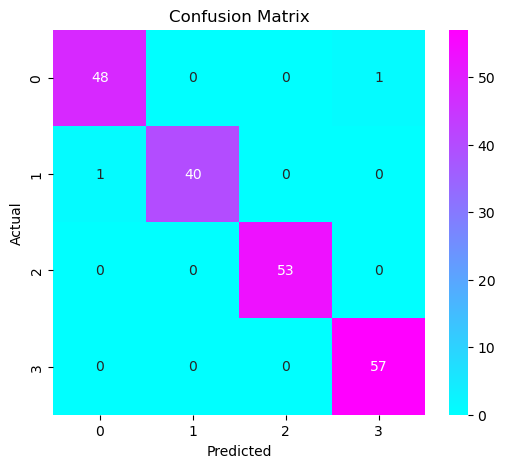

In [14]:
# Calculate metrics for nonlinear model
nonlinear_precision = precision_macro(
    y_true=y_test,
    y_pred=test_pred,
    num_classes=NUM_CLASSES
)
print("Nonlinear model precision:", nonlinear_precision)

nonlinear_recall = recall_macro(
    y_true=y_test,
    y_pred=test_pred,
    num_classes=NUM_CLASSES
)
print("Nonlinear model recall:", nonlinear_recall)

nonlinear_f1_score = f1_score_macro(
    y_true=y_test,
    y_pred=test_pred,
    num_classes=NUM_CLASSES
)
print("Nonlinear model f1 score:", nonlinear_f1_score)

metrics_df.loc[len(metrics_df)] = {
    "train_loss": loss.item(),
    "train_accuracy": accuracy,
    "precision": nonlinear_precision,
    "recall": nonlinear_recall,
    "f1_score": nonlinear_f1_score,
}

nonlinear_confusion_matrix = get_confusion_matrix(
    y_true=y_test,
    y_pred=test_pred,
    num_classes=NUM_CLASSES,
    normalize=None,
    cmap="cool"
)

In [15]:
# Use pandas dataframe to compare model metrics
metrics_df

,train_loss,train_accuracy,precision,recall,f1_score
0,0.032008,99.125,99.500000,99.561403,99.526236
1,0.157207,98.625,99.058761,98.880040,98.963763
